# ２次元平面に教師ラベル〇△を表示する

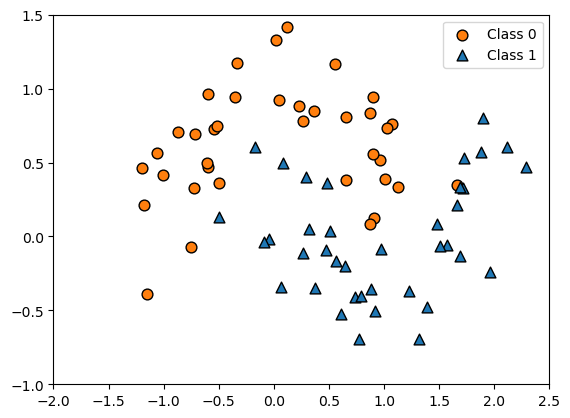

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patch
from sklearn.datasets import make_moons

 
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
x_train, x_test, y_train, y_test = train_test_split(X, y,  random_state=0)

fig, ax = plt.subplots()
 
ax.scatter(x_train[y_train==0][:, 0], x_train[y_train==0][:, 1],
    ec='k', s=60, marker='o', fc='tab:orange', label="Class 0")
ax.scatter(x_train[y_train==1][:, 0], x_train[y_train==1][:, 1],
    ec='k', s=60, marker='^', fc='tab:blue', label="Class 1")
 
x0_min, x0_max = -2, 2.5
x1_min, x1_max = -1, 1.5
  
ax.set_xlim(x0_min, x0_max)
ax.set_ylim(x1_min, x1_max)
ax.legend()
 
plt.show()


# 純度最大化する決定境界と決定木との対応
http://taustation.com/decision_tree_boundary_drawing/

In [5]:
!pip install mglearn

   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ---------------------------------------- 581.4/581.4 kB 4.5 MB/s eta 0:00:00


# 決定木のハイパーパラメータを変更してみる
1. ハイパーパラメータを変更して線を増やすほど、仕切られた箱の中の純度が上がることに注目
2. 該当箇所はDecisionTreeClassifier(max_depth=1

training score: 0.9222222222222223
test score: 0.8666666666666667


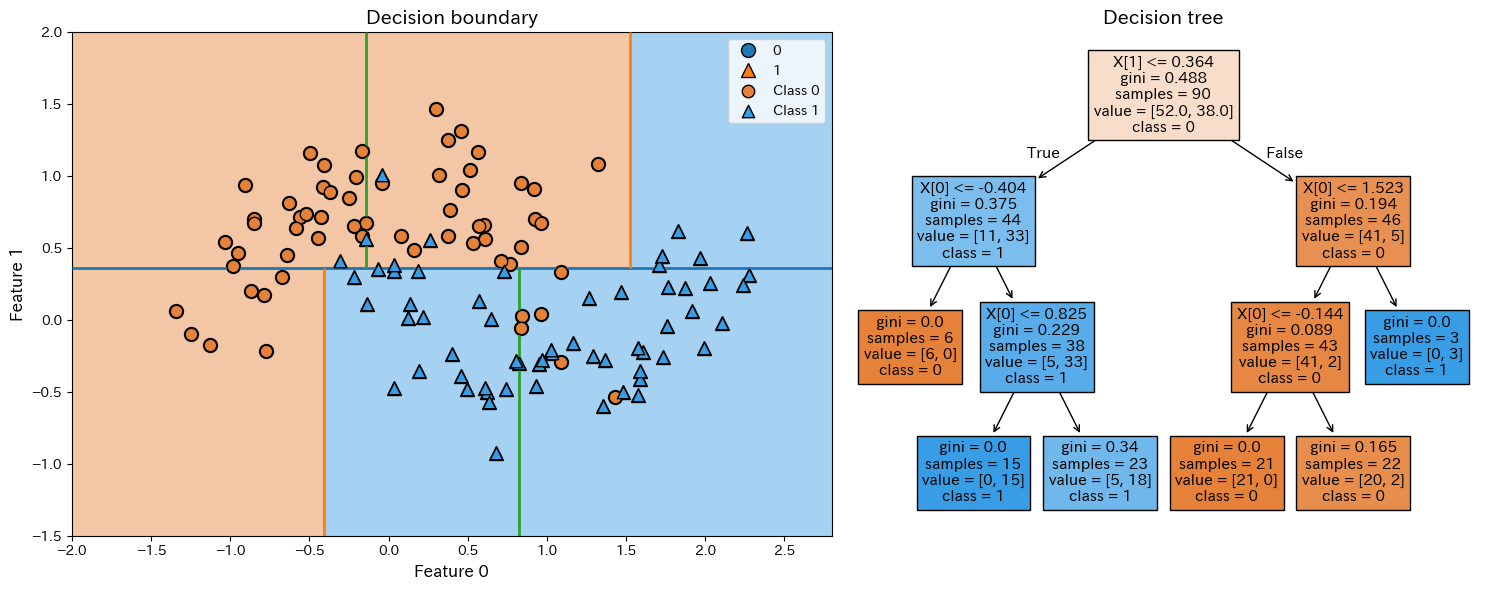

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
# ==================================================
# 1. データ作成
# ==================================================
X, y = make_moons( n_samples=120,  noise=0.25,  random_state=3)
x_train, x_test, y_train, y_test = train_test_split( X,  y, random_state=0)



# ==================================================
# 2. 決定木
# ==================================================
tree = DecisionTreeClassifier( max_depth=3,  random_state=0)
tree.fit(x_train, y_train)


# ==================================================
# 3. 精度
# ==================================================
training_score = tree.score(x_train, y_train)
test_score = tree.score(x_test, y_test)

print("training score:", training_score)
print("test score:", test_score)


# ==================================================
# 4. 木の分割線を再帰的に描く関数
# ==================================================
def draw_tree_splits(  ax, model, node_id, xmin,  xmax,  ymin,  ymax,  depth=0):

    t = model.tree_
    # leafなら終了
    if t.children_left[node_id] == t.children_right[node_id]:
        return
    feature = t.feature[node_id]
    threshold = t.threshold[node_id]

    # 深さごとに線を変える
    line_colors = [ "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple" ]
    color = line_colors[depth % len(line_colors)]

    # ------------------------------------------------
    # Feature 0による分割 → 縦線
    # ------------------------------------------------
    if feature == 0:

        ax.vlines(threshold, ymin, ymax,  color=color, linewidth=2.0,  zorder=4  )
        # 左側の子ノード
        draw_tree_splits( ax, model,  t.children_left[node_id], xmin,  threshold,  ymin,   ymax,  depth + 1  )
        # 右側の子ノード
        draw_tree_splits( ax, model,  t.children_right[node_id], threshold, xmax, ymin,  ymax,  depth + 1    )

    # ------------------------------------------------
    # Feature 1による分割 → 横線
    # ------------------------------------------------
    elif feature == 1:

        ax.hlines(threshold, xmin,  xmax, color=color, linewidth=2.0, zorder=4  )
        # 左側の子ノード
        # X[1] <= threshold
        draw_tree_splits(  ax, model,  t.children_left[node_id],  xmin,   xmax,  ymin, threshold, depth + 1  )
        # 右側の子ノード
        # X[1] > threshold
        draw_tree_splits(ax,model, t.children_right[node_id], xmin,  xmax, threshold, ymax, depth + 1 )


# ==================================================
# 5. 描画
# ==================================================
fig, axes = plt.subplots( 1, 2,  figsize=(15, 6),  gridspec_kw={"width_ratios": [1.2, 1]})


# ==================================================
# 左：決定境界
# ==================================================

x_min, x_max = -2.0, 2.8
y_min, y_max = -1.5, 2.0


# --------------------------------------------------
# 背景用の格子
# --------------------------------------------------
xx, yy = np.meshgrid( np.linspace(x_min, x_max, 500),   np.linspace(y_min, y_max, 500))
Z = tree.predict(  np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# --------------------------------------------------
# 最終的な分類領域を塗る
# --------------------------------------------------

decision_cmap = ListedColormap([
    "#e58139",   # Class 0 : orange
    "#399de5"    # Class 1 : blue
])

axes[0].contourf(  xx,   yy,   Z,  levels=[-0.5, 0.5, 1.5],   cmap=decision_cmap,    alpha=0.45,    zorder=1)

# --------------------------------------------------
# 各段階の境界線をすべて重ねる
# --------------------------------------------------
draw_tree_splits( axes[0],  tree,    node_id=0,  xmin=x_min,  xmax=x_max,    ymin=y_min,    ymax=y_max)


# --------------------------------------------------
# データ点
# --------------------------------------------------
mglearn.discrete_scatter( X[:, 0],   X[:, 1],   y,  ax=axes[0])
axes[0].scatter( X[y == 0, 0],   X[y == 0, 1],   c="#e58139",    marker="o",    edgecolor="black",  s=80,  label="Class 0",   zorder=5)
axes[0].scatter(X[y == 1, 0],    X[y == 1, 1],   c="#399de5",   marker="^",    edgecolor="black", s=80, label="Class 1",  zorder=5)
axes[0].legend()

# --------------------------------------------------
# 軸設定
# --------------------------------------------------
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[0].set_xticks( np.arange(-2.0, 3.0, 0.5))
axes[0].set_yticks(np.arange(-1.5, 2.1, 0.5))
axes[0].set_xlabel( "Feature 0",  fontsize=12)
axes[0].set_ylabel( "Feature 1",  fontsize=12)
axes[0].set_title( "Decision boundary", fontsize=14)


# ==================================================
# 右：決定木
# ==================================================
plot_tree( tree,   ax=axes[1],    filled=True,    rounded=False,    class_names=["0", "1"],    feature_names=["X[0]", "X[1]"],    fontsize=11)
axes[1].set_title("Decision tree",  fontsize=14)


# ==================================================
# 6. レイアウト
# ==================================================
plt.tight_layout()
plt.show()

# 決定木コーディング
 - 決定木のコーディングをよく観察すること。教師あり機械学習の典型的なパターン（オブジェクト指向）になっている
 - 以下のコードが機械学習の本体。実は、KNNと全く同じコードパターン（モデル以外）になっていることに注目

```python

X, y = make_moons(n_samples=120, noise=0.25, random_state=3)
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=0)
#max_depthは木の深さパラメータ
tree = DecisionTreeClassifier(max_depth=1,random_state=0)

#訓練データで学習（純度最大化する縦線、横線を見つける）
tree.fit(x_train, y_train)
training_score = tree.score(x_train,y_train)

```
 
 ### 演習
 - 訓練精度、テスト精度も表示されるのでmax_depthを1～9に変化させてどう変化するかも確認する

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from pylab import rcParams


#
#上記と同様にして、テストデータ20サンプル取得
X, y = make_moons(n_samples=120, noise=0.25, random_state=3)
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=0)


#max_depthは木の深さパラメータ
tree = DecisionTreeClassifier(max_depth=3,random_state=0)

#訓練データで学習（純度最大化する縦線、横線を見つける）
tree.fit(x_train, y_train)
training_score = tree.score(x_train,y_train)
print('training score:', training_score)
test_score = tree.score(x_test,y_test)
print('test score', test_score)



training score: 0.9222222222222223
test score 0.8666666666666667


# 学習曲線

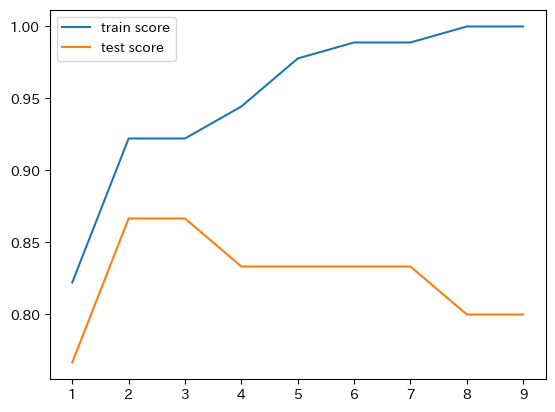

In [43]:
train_acc=[]
test_acc=[]
fig=plt.figure()
for i in range(1,10):
    tree = DecisionTreeClassifier(max_depth=i,random_state=0)
    tree.fit(x_train,y_train)
    
    train_acc.append(tree.score(x_train,y_train))
    test_acc.append(tree.score(x_test,y_test))
    

ax = fig.add_subplot(1,1,1)
x=range(1,10)
ax.plot(x,train_acc,label='train score')
ax.plot(x,test_acc,label='test score')
ax.legend()
plt.show()

# 演習　iris datasetを決定木で分類
1. Iris detasetを決定木を使って分類せよ

In [46]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

iris_dataset = load_iris()
x_train,x_test,y_train,y_test = train_test_split(iris_dataset['data'],iris_dataset['target'],random_state=0)

#max_depthは木の深さパラメータ
tree = DecisionTreeClassifier(max_depth=3,random_state=0)

#訓練データで学習（純度最大化する縦線、横線を見つける）
tree.fit(x_train, y_train)
training_score = tree.score(x_train,y_train)
print('training score:', training_score)
test_score = tree.score(x_test,y_test)
print('test score', test_score)



training score: 0.9821428571428571
test score 0.9736842105263158


# プリン/シュークリームを決定木で判別する  
 - 重要特徴量が表示される  
 - 決定木が表示される  
 - 訓練精度　予測精度が表示される

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from pylab import rcParams
import japanize_matplotlib
import pandas as pd
import sklearn
url = "https://github.com/ueharaLab/datascience_python9/raw/main/cookpad_texture_bow.csv"
cookpad_df = pd.read_csv( url, header=None)
#cookpad_df = pd.read_csv('cookpad_texture_bow.csv', encoding='ms932', sep=',')
cookpad_df

,keyword,title,texture,tsukurepo,しっかり,しっとり,すかっ,つるっ,とろける,とろっ,...,もちもち,カリカリ,カリッ,クリーミー,サクサク,パリッ,ミルキー,分離,柔らかい,濃厚
0,シュークリーム,ティラミスシュークリーム,[],クッキーシューに！膨らみ失敗したけど味は大人スイーツで好評でした コーヒー味のシューいいです...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,シュークリーム,シュークリーム(シュー生地、クリーム),"['しっかり', 'ふわふわ']",シュー皮を作りました。生地が弛かったようで高さが全く出ずペチャンコです(T_T)また今度挑戦...,0.628979,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,シュークリーム,しぼりなし！失敗しないシュークリーム生地,['しっかり'],絞り出さないので簡単ですね!適当に出しましたが、ちゃんと膨らみました。ありがとうございます!...,1.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,シュークリーム,失敗なしの簡単シュークリーム,[],見た目はイマイチになりましたが膨らみました。小麦粉を火にかけすぎたかな？リベンジします！ す...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,シュークリーム,ちょっと豪華に☆シュークリーム,[],今宵のデザートに。今晩は。ワッフルで｡庭で出来た苺とミントを添えて。寒くなりました。私の誕生...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,プリン,おうちカフェ黒蜜みるくぷりん♪,"['ぷるぷる', 'ぷるぷる', 'ぷるぷる', 'ぷるぷる']",苺シロップと黒蜜の2種類作りました！プルプルでおいしかったです(^^) 市販の黒蜜を使ってホ...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
381,プリン,離乳食☆電子レンジで簡単卵プリン,[],レンジで簡単にできてありがたいです。食の細い息子もパクパク食べてくれました！ 初手作りプリン...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
382,プリン,低糖質プリン,[],ほんのりした甘みでとてもおいしいです☆\n材料をまぜお鍋でコトコト…\n食べたいときにすぐ作...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
383,プリン,簡単。昔ながらの固いプリン！,"['硬い', '硬い', '硬い', '硬い']",旦那さんが固いプリンが好きなので喜んでくれました！ 固めのプリン、カラメルつきで作りました。...,0.000000,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


0.711340206185567


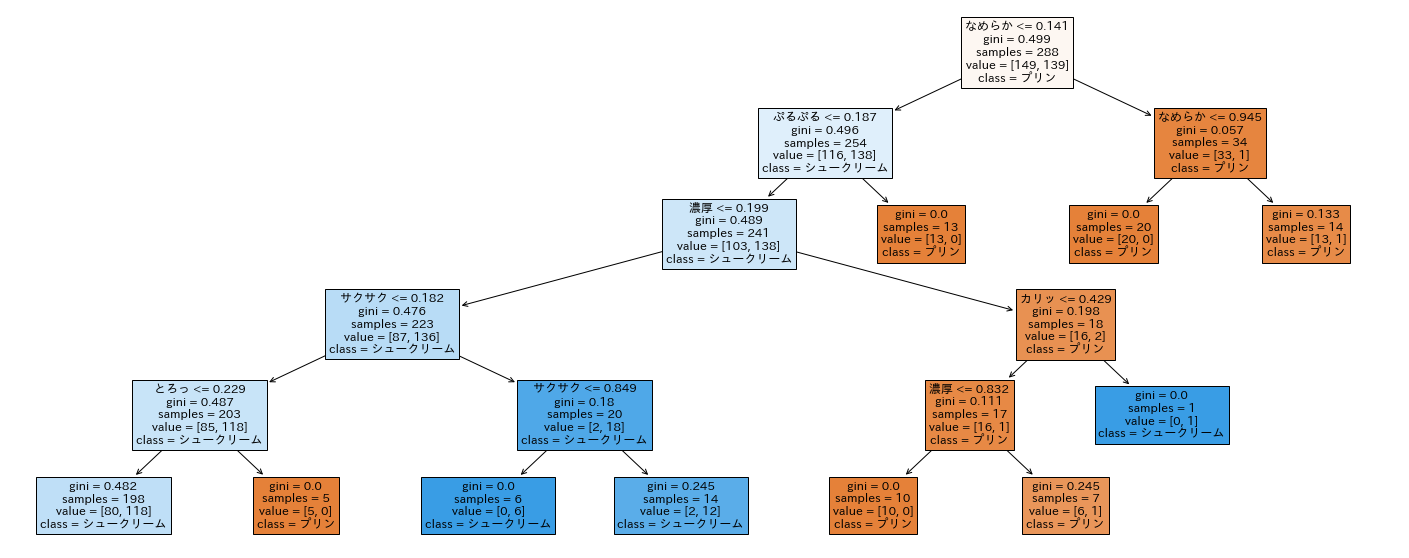

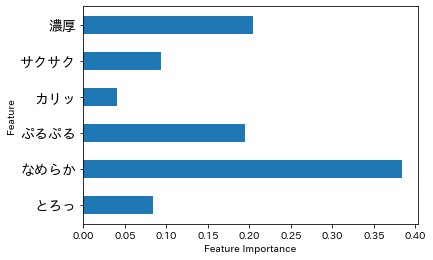

In [10]:

#texture_bow= pd.read_csv('cookpad_texture_bow.csv', encoding='ms932', sep=',',skiprows=0)

X = cookpad_df.iloc[:,4:]

# 重要　ツリーで表示する教師ラベルは、訓練データ0,1....の番号順に対応づいたラベルが表示されるので
# 以下のようにラベル名と訓練データのラベル番号を予め対応付ける必要がある
# この処理をやらずに教師ラベルのままでtrain_test_splitのyに放り込むと、シャッフルしてたまたま先に
# くる教師ラベルに0を対応付けるので、ツリーの教師ラベルが真逆に表示されることがある
labels=list(set(cookpad_df['keyword']))
label_dic = {label:i for i, label in enumerate(labels)}
y= [label_dic[label] for label in cookpad_df['keyword']]

header = cookpad_df.columns.tolist()[4:]

fig=plt.figure(figsize=(25,10))
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


tree = DecisionTreeClassifier(max_depth=5, random_state=0)
tree.fit(X_train, y_train)
y_predict=tree.predict(X_test)
print(tree.score(X_test,y_test))
plot_tree(tree,feature_names=header,fontsize=12,class_names=labels,filled=True, )
plt.show()


feature_name=[]
feature_importances_nonzero=[]
for feature_label, feature_figure in zip(header,tree.feature_importances_):
    if feature_figure >0:
        feature_name.append(feature_label)
        feature_importances_nonzero.append(feature_figure)
    
#print(feature_importances_nonzero)
plt.barh(range(len(feature_name)),feature_importances_nonzero,height=0.5)
plt.yticks(np.arange(len(feature_name)),feature_name,fontsize=14)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()


# 演習　パンケーキ/ホットケーキの判別
 #### dataset_tf_cookpad.csvはパンケーキ、ホットケーキを素材リスト特徴量で判別するためのデータセットである。これにもとづき以下のように決定木を生成せよ
 - 上記のプログラムを用いて決定木、重要特徴量を描け
 - 木の深さを1-49まで動かして、訓練精度、予測精度を表示し、sweet spotがどの辺にあるかを確認せよ

0.54


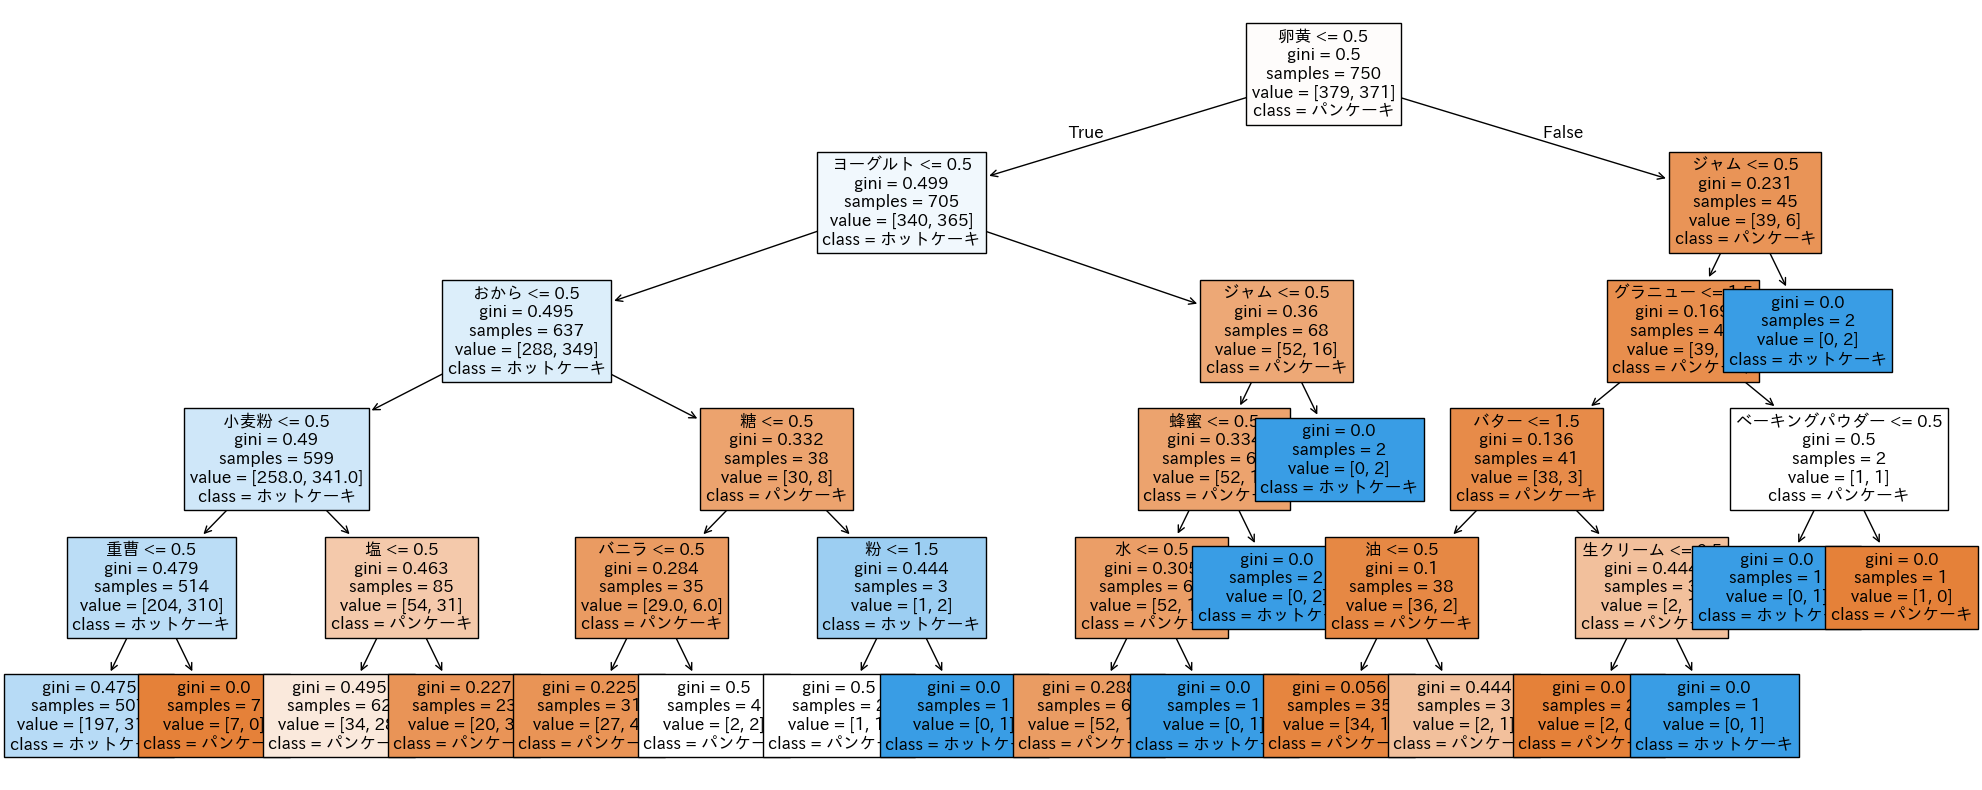

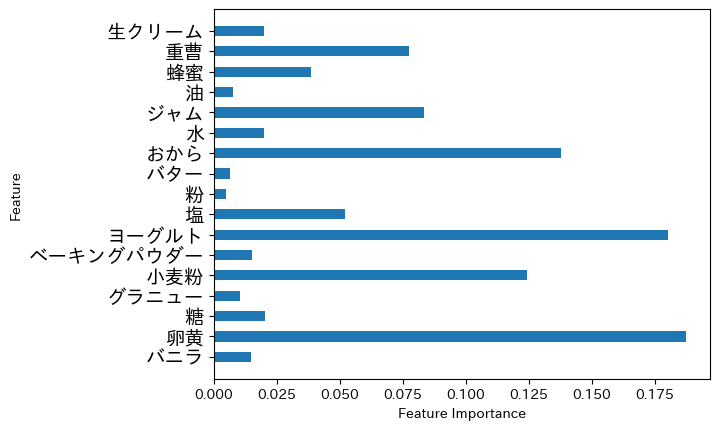

In [49]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from pylab import rcParams
import japanize_matplotlib
import pandas as pd
import sklearn


url = "https://github.com/ueharaLab/datascience_python9/raw/main/dataset_tf_cookpad.csv"
cookpad_df = pd.read_csv( url, header=None)

#cookpad_df= pd.read_csv('dataset_tf_cookpad.csv', encoding='ms932', sep=',',skiprows=0)

X = cookpad_df.iloc[:,3:]

labels=list(set(cookpad_df['label']))
label_dic = {label:i for i, label in enumerate(labels)}
y= [label_dic[label] for label in cookpad_df['label']]


header = cookpad_df.columns.tolist()[3:]

fig=plt.figure(figsize=(25,10))
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
tree = DecisionTreeClassifier(max_depth=5, random_state=0)
tree.fit(X_train, y_train)
y_predict=tree.predict(X_test)
print(tree.score(X_test,y_test))
plot_tree(tree,feature_names=header,fontsize=12,class_names=labels,filled=True, )
plt.show()


feature_name=[]
feature_importances_nonzero=[]
for feature_label, feature_figure in zip(header,tree.feature_importances_):
    if feature_figure >0:
        feature_name.append(feature_label)
        feature_importances_nonzero.append(feature_figure)
    
#print(feature_importances_nonzero)
plt.barh(range(len(feature_name)),feature_importances_nonzero,height=0.5)
plt.yticks(np.arange(len(feature_name)),feature_name,fontsize=14)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()


training score: 0.5493333333333333
test score 0.532
training score: 0.584
test score 0.564
training score: 0.6106666666666667
test score 0.58
training score: 0.6373333333333333
test score 0.6
training score: 0.656
test score 0.608
training score: 0.6666666666666666
test score 0.596
training score: 0.6906666666666667
test score 0.612
training score: 0.7026666666666667
test score 0.608
training score: 0.7226666666666667
test score 0.596
training score: 0.7333333333333333
test score 0.588
training score: 0.7426666666666667
test score 0.596
training score: 0.7546666666666667
test score 0.596
training score: 0.776
test score 0.6
training score: 0.788
test score 0.6
training score: 0.8066666666666666
test score 0.576
training score: 0.812
test score 0.596
training score: 0.8213333333333334
test score 0.588
training score: 0.8266666666666667
test score 0.592
training score: 0.8293333333333334
test score 0.596
training score: 0.836
test score 0.596
training score: 0.8466666666666667
test score

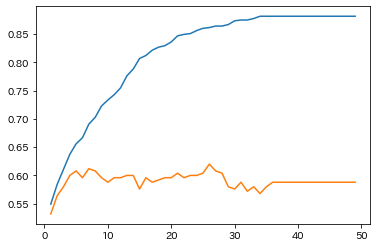

# XGBoost 
決定木系で最もパフォーマンスがいいとされているがパラメータが多すぎてチューニングが大変  
https://di-acc2.com/programming/python/23577/  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import re
import pickle


cookpad_df = pd.read_csv('dataset_tf_cookpad.csv', encoding='ms932', sep=',')
labels = cookpad_df['label_digits'].values
features = cookpad_df.iloc[:,3:].values
feature_names = cookpad_df.iloc[:,3:].columns.tolist()
label_names = cookpad_df['label'].values.tolist()

X_train,X_test,Y_train,Y_test = train_test_split(features,labels,random_state=3)




dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)
param = {'max_depth': 40, 'eta': 1,'learning_rate':1 , 'objective': 'multi:softmax', 'num_class': 2}

bst = xgb.train(param, dtrain, num_boost_round=500)

#a = np.array([1, 2, 3], dtype='int64')
pred_train = bst.predict(dtrain)
pred_test = bst.predict(dtest)
#print(pred_test)
#print(np.array(Y_test))
score = accuracy_score(Y_train, pred_train)
print('train score:{0:.4f}'.format(score))
score = accuracy_score(Y_test, pred_test)
print('test score:{0:.4f}'.format(score))

train score:0.8813
test score:0.6240
